# HOG + SVM — Head & Person Detection 

In [1]:
import os, cv2, gc, random, joblib, time
import numpy as np
from tqdm import tqdm
from glob import glob
from skimage.feature import hog
from sklearn.linear_model import SGDClassifier
from sklearn.utils.class_weight import compute_class_weight
import imutils
from imutils.object_detection import non_max_suppression
from sklearn.metrics import (
    classification_report, accuracy_score,
    precision_score, recall_score, f1_score
)

In [ ]:
TRAIN_IMAGE_DIR = "train/images"
TRAIN_LABEL_DIR = "train/labels"
VAL_IMAGE_DIR   = "valid/images"
VAL_LABEL_DIR   = "valid/labels"
SAVE_DIR        = "dataset"          

# ── YOLO class IDs  ─────────────────────────────────
HEAD_CLASS_ID   = 0
PERSON_CLASS_ID = 1

# ── Window sizes (width, height) ──────────────────────────────────────────
PERSON_WINDOW = (48,96)
HEAD_WINDOW = (16, 16)

# ── HOG ───────────────────────────────────────────────────────────────────
HOG_ORIENTATIONS    = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)

# ── Dataset ───────────────────────────────────────────────────────────────
NEGATIVE_SAMPLES_PER_IMG = 20
IOU_THRESHOLD            = 0.3
EXTRACT_CHUNK_SIZE       = 500    

# ── Training ──────────────────────────────────────────────────────────────
TRAIN_CHUNK = 20000               
SGD_EPOCHS  = 3
N_JOBS      = -1                 

# ── HNM ───────────────────────────────────────────────────────────────────
HNM_IMAGES    = 500               
HNM_IMG_CHUNK = 100
HNM_STEP      = 8
HNM_SCALES    = [1.0, 0.75, 0.5]

# ── Inference ─────────────────────────────────────────────────────────────
DETECT_STEP          = 8
DETECT_SCALES = [
    1.0,
    0.9,
    0.8,
    0.7,
    0.6,
    0.5,
    0.4
]
PERSON_DETECT_THRESH = 1.5
HEAD_DETECT_THRESH   = 2
NMS_THRESH           = 0.1

os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Train images : {len(glob(os.path.join(TRAIN_IMAGE_DIR,'*.jpg')))}")
print(f"Val   images : {len(glob(os.path.join(VAL_IMAGE_DIR,'*.jpg')))}")

Train images : 14431
Val   images : 4810


## Helper functions

In [22]:
def read_yolo_labels(label_path, img_w, img_h):
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls, xc, yc, w, h = map(float, parts)
            boxes.append([
                int(cls),
                int((xc - w/2)*img_w), int((yc - h/2)*img_h),
                int((xc + w/2)*img_w), int((yc + h/2)*img_h)
            ])
    return boxes


def compute_iou(boxA, boxB):
    xA, yA = max(boxA[0],boxB[0]), max(boxA[1],boxB[1])
    xB, yB = min(boxA[2],boxB[2]), min(boxA[3],boxB[3])
    inter  = max(0,xB-xA)*max(0,yB-yA)
    aA = max(0,(boxA[2]-boxA[0])*(boxA[3]-boxA[1]))
    aB = max(0,(boxB[2]-boxB[0])*(boxB[3]-boxB[1]))
    u  = aA+aB-inter
    return inter/u if u > 0 else 0.0


def extract_hog(image, window_size):
    resized = cv2.resize(image, window_size)
    gray    = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    return hog(
        gray,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm="L2-Hys",
        transform_sqrt=True,
    ).astype(np.float32)


def sliding_window(image, step, window_size):
    win_w, win_h = window_size
    for y in range(0, image.shape[0]-win_h, step):
        for x in range(0, image.shape[1]-win_w, step):
            yield x, y, image[y:y+win_h, x:x+win_w]

## Feature extraction with checkpoints

Saves a `.npz` every `EXTRACT_CHUNK_SIZE` images.  
**Safe to rerun** — already-saved chunks are skipped automatically.

In [23]:
def extract_chunk(image_paths, label_dir):
    X_p, y_p, X_h, y_h = [], [], [], []
    p_win_w, p_win_h = PERSON_WINDOW
    h_win_w, h_win_h = HEAD_WINDOW

    for img_path in image_paths:
        image = cv2.imread(img_path)
        if image is None:
            continue
        img_h, img_w = image.shape[:2]

        lp    = os.path.join(label_dir,
                              os.path.splitext(os.path.basename(img_path))[0]+".txt")
        boxes     = read_yolo_labels(lp, img_w, img_h)
        all_boxes = [[x1,y1,x2,y2] for _,x1,y1,x2,y2 in boxes]

        for cls, x1, y1, x2, y2 in boxes:
            if cls == PERSON_CLASS_ID:
                pad = 5
                x1p = max(0,x1-pad); y1p = max(0,y1-pad)
                x2p = min(img_w,x2+pad); y2p = min(img_h,y2+pad)
                crop = image[y1p:y2p, x1p:x2p]
                if crop.size == 0: continue
                X_p.append(extract_hog(crop, PERSON_WINDOW)); y_p.append(1)

            elif cls == HEAD_CLASS_ID:
                pad = 1
                x1p = max(0,x1-pad); y1p = max(0,y1-pad)
                x2p = min(img_w,x2+pad); y2p = min(img_h,y2+pad)
                crop = image[y1p:y2p, x1p:x2p]
                if crop.size == 0: continue
                X_h.append(extract_hog(crop, HEAD_WINDOW)); y_h.append(1)

        # Person negatives
        for _ in range(NEGATIVE_SAMPLES_PER_IMG):
            for _ in range(50):
                if img_w<=p_win_w or img_h<=p_win_h: break
                rx1 = random.randint(0, img_w-p_win_w)
                ry1 = random.randint(0, img_h-p_win_h)
                cand = [rx1,ry1,rx1+p_win_w,ry1+p_win_h]
                if any(compute_iou(cand,gt)>IOU_THRESHOLD for gt in all_boxes): continue
                crop = image[ry1:ry1+p_win_h, rx1:rx1+p_win_w]
                if crop.shape[:2]!=(p_win_h,p_win_w): continue
                X_p.append(extract_hog(crop, PERSON_WINDOW)); y_p.append(0); break

        # Head negatives
        for _ in range(NEGATIVE_SAMPLES_PER_IMG):
            for _ in range(50):
                if img_w<=h_win_w or img_h<=h_win_h: break
                rx1 = random.randint(0, img_w-h_win_w)
                ry1 = random.randint(0, img_h-h_win_h)
                cand = [rx1,ry1,rx1+h_win_w,ry1+h_win_h]
                if any(compute_iou(cand,gt)>IOU_THRESHOLD for gt in all_boxes): continue
                crop = image[ry1:ry1+h_win_h, rx1:rx1+h_win_w]
                if crop.shape[:2]!=(h_win_h,h_win_w): continue
                X_h.append(extract_hog(crop, HEAD_WINDOW)); y_h.append(0); break

    return (
        np.array(X_p,dtype=np.float32), np.array(y_p,dtype=np.int32),
        np.array(X_h,dtype=np.float32), np.array(y_h,dtype=np.int32)
    )


def extract_with_checkpoints(image_dir, label_dir, split_name):
    chunk_dir = os.path.join(SAVE_DIR, f"chunks_{split_name}")
    os.makedirs(chunk_dir, exist_ok=True)

    image_paths = sorted(glob(os.path.join(image_dir, "*.jpg")))
    total    = len(image_paths)
    n_chunks = (total + EXTRACT_CHUNK_SIZE - 1) // EXTRACT_CHUNK_SIZE
    print(f"[{split_name}] {total} images → {n_chunks} chunks of {EXTRACT_CHUNK_SIZE}")

    for i in range(n_chunks):
        chunk_path = os.path.join(chunk_dir, f"chunk_{i:04d}.npz")
        if os.path.exists(chunk_path):
            print(f"  chunk {i+1}/{n_chunks} already saved — skipping")
            continue

        batch = image_paths[i*EXTRACT_CHUNK_SIZE:(i+1)*EXTRACT_CHUNK_SIZE]
        t0    = time.time()
        Xp, yp, Xh, yh = extract_chunk(batch, label_dir)

        np.savez_compressed(chunk_path,
                            X_person=Xp, y_person=yp,
                            X_head=Xh,   y_head=yh)
        print(f"  chunk {i+1}/{n_chunks}: "
              f"person={Xp.shape[0]} head={Xh.shape[0]} "
              f"({time.time()-t0:.0f}s)")
        del Xp, yp, Xh, yh; gc.collect()

    print(f"[{split_name}] Extraction complete.")
    return chunk_dir


train_chunk_dir = extract_with_checkpoints(TRAIN_IMAGE_DIR, TRAIN_LABEL_DIR, "train")
val_chunk_dir   = extract_with_checkpoints(VAL_IMAGE_DIR,   VAL_LABEL_DIR,   "val")

[train] 14431 images → 29 chunks of 500
  chunk 1/29: person=18707 head=18707 (66s)
  chunk 2/29: person=18676 head=18676 (51s)
  chunk 3/29: person=21483 head=21483 (56s)
  chunk 4/29: person=22172 head=22172 (57s)
  chunk 5/29: person=20623 head=20623 (53s)
  chunk 6/29: person=19497 head=19497 (58s)
  chunk 7/29: person=19844 head=19844 (66s)
  chunk 8/29: person=20447 head=20447 (76s)
  chunk 9/29: person=22519 head=22519 (82s)
  chunk 10/29: person=20182 head=20182 (89s)
  chunk 11/29: person=18796 head=18796 (78s)
  chunk 12/29: person=21507 head=21507 (85s)
  chunk 13/29: person=18705 head=18705 (72s)
  chunk 14/29: person=18653 head=18653 (50s)
  chunk 15/29: person=21363 head=21363 (58s)
  chunk 16/29: person=25177 head=25177 (69s)
  chunk 17/29: person=23708 head=23708 (95s)
  chunk 18/29: person=22162 head=22162 (65s)
  chunk 19/29: person=25572 head=25572 (73s)
  chunk 20/29: person=27317 head=27317 (79s)
  chunk 21/29: person=16973 head=16973 (51s)
  chunk 22/29: person=21

## Merge chunks → final .npy files

In [24]:
def merge_chunks(chunk_dir, out_prefix):
    chunk_files = sorted(glob(os.path.join(chunk_dir, "chunk_*.npz")))
    print(f"Merging {len(chunk_files)} chunks...")
    all_Xp, all_yp, all_Xh, all_yh = [], [], [], []

    for cf in tqdm(chunk_files):
        d = np.load(cf)
        all_Xp.append(d["X_person"]); all_yp.append(d["y_person"])
        all_Xh.append(d["X_head"]);   all_yh.append(d["y_head"])
        del d; gc.collect()

    Xp = np.concatenate(all_Xp); yp = np.concatenate(all_yp)
    Xh = np.concatenate(all_Xh); yh = np.concatenate(all_yh)
    del all_Xp, all_yp, all_Xh, all_yh; gc.collect()

    np.save(out_prefix+"_X_person.npy", Xp)
    np.save(out_prefix+"_y_person.npy", yp)
    np.save(out_prefix+"_X_head.npy",   Xh)
    np.save(out_prefix+"_y_head.npy",   yh)

    print(f"Person: {Xp.shape}  labels: {np.bincount(yp)}")
    print(f"Head  : {Xh.shape}  labels: {np.bincount(yh)}")
    del Xp, yp, Xh, yh; gc.collect()


merge_chunks(train_chunk_dir, os.path.join(SAVE_DIR, "train"))
merge_chunks(val_chunk_dir,   os.path.join(SAVE_DIR, "val"))

Merging 29 chunks...


100%|██████████| 29/29 [00:47<00:00,  1.64s/it]


Person: (614112, 1980)  labels: [288620 325492]
Head  : (614112, 36)  labels: [288620 325492]
Merging 10 chunks...


100%|██████████| 10/10 [00:16<00:00,  1.69s/it]


Person: (207175, 1980)  labels: [ 96200 110975]
Head  : (207175, 36)  labels: [ 96200 110975]


## Memory-map final arrays

In [25]:
X_train_person_mm = np.load(os.path.join(SAVE_DIR,"train_X_person.npy"), mmap_mode='r')
y_train_person_mm = np.load(os.path.join(SAVE_DIR,"train_y_person.npy"), mmap_mode='r')
X_train_head_mm   = np.load(os.path.join(SAVE_DIR,"train_X_head.npy"),   mmap_mode='r')
y_train_head_mm   = np.load(os.path.join(SAVE_DIR,"train_y_head.npy"),   mmap_mode='r')

X_val_person_mm   = np.load(os.path.join(SAVE_DIR,"val_X_person.npy"),   mmap_mode='r')
y_val_person_mm   = np.load(os.path.join(SAVE_DIR,"val_y_person.npy"),   mmap_mode='r')
X_val_head_mm     = np.load(os.path.join(SAVE_DIR,"val_X_head.npy"),     mmap_mode='r')
y_val_head_mm     = np.load(os.path.join(SAVE_DIR,"val_y_head.npy"),     mmap_mode='r')

print(f"Person — train: {X_train_person_mm.shape}  val: {X_val_person_mm.shape}")
print(f"Head   — train: {X_train_head_mm.shape}    val: {X_val_head_mm.shape}")

Person — train: (614112, 1980)  val: (207175, 1980)
Head   — train: (614112, 36)    val: (207175, 36)


## Train both SVMs

In [27]:
def make_svm():
    return SGDClassifier(
        loss="modified_huber", alpha=1e-4,
        max_iter=1, tol=None,
        random_state=42, n_jobs=N_JOBS
    )


def compute_weights(y_mm):
    y   = y_mm[:].astype(int)
    cls = np.array([0, 1])
    w   = compute_class_weight('balanced', classes=cls, y=y)
    del y; gc.collect()
    return {0: w[0], 1: w[1]}, cls


def train_chunked(svm, X_mm, y_mm, weight_map, classes,
                  label, save_path, start_epoch=0):
    """
    Incremental training with per-epoch checkpoints.
    Set start_epoch to resume from a saved checkpoint.
    """
    n   = X_mm.shape[0]
    idx = np.arange(n)

    for epoch in range(start_epoch, SGD_EPOCHS):
        np.random.shuffle(idx)
        chunks = [idx[i:i+TRAIN_CHUNK] for i in range(0, n, TRAIN_CHUNK)]
        print(f"[{label}] Epoch {epoch+1}/{SGD_EPOCHS} — {len(chunks)} chunks")
        t0 = time.time()

        for chunk_idx in tqdm(chunks, desc=f"{label} epoch {epoch+1}"):
            X_c = X_mm[chunk_idx].astype(np.float32)
            y_c = y_mm[chunk_idx].astype(np.int32)
            sw  = np.where(y_c==1, weight_map[1], weight_map[0]).astype(np.float32)
            svm.partial_fit(X_c, y_c, classes=classes, sample_weight=sw)
            del X_c, y_c, sw; gc.collect()

        ckpt = save_path.replace(".pkl", f"_epoch{epoch+1}.pkl")
        joblib.dump(svm, ckpt)
        print(f"  [{label}] Epoch {epoch+1} done in "
              f"{(time.time()-t0)/60:.1f} min → {ckpt}")

    joblib.dump(svm, save_path)
    print(f"[{label}] Training complete → {save_path}")
    return svm


# ── Person SVM ──────────────────────────────────────────────────────────────
print("=" * 55)
print("PERSON SVM")
print("=" * 55)
svm_person = make_svm()
wmap_person, classes = compute_weights(y_train_person_mm)
print(f"Class weights → bg: {wmap_person[0]:.3f}  person: {wmap_person[1]:.3f}")
svm_person = train_chunked(
    svm_person, X_train_person_mm, y_train_person_mm,
    wmap_person, classes, "PERSON",
    os.path.join(SAVE_DIR, "svm_person.pkl")
)

# ── Head SVM ────────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("HEAD SVM")
print("=" * 55)
svm_head = make_svm()
wmap_head, _ = compute_weights(y_train_head_mm)
print(f"Class weights → bg: {wmap_head[0]:.3f}  head: {wmap_head[1]:.3f}")
svm_head = train_chunked(
    svm_head, X_train_head_mm, y_train_head_mm,
    wmap_head, classes, "HEAD",
    os.path.join(SAVE_DIR, "svm_head.pkl")
)

PERSON SVM
Class weights → bg: 1.064  person: 0.943
[PERSON] Epoch 1/3 — 31 chunks


PERSON epoch 1: 100%|██████████| 31/31 [00:28<00:00,  1.10it/s]


  [PERSON] Epoch 1 done in 0.5 min → dataset\svm_person_epoch1.pkl
[PERSON] Epoch 2/3 — 31 chunks


PERSON epoch 2: 100%|██████████| 31/31 [00:26<00:00,  1.19it/s]


  [PERSON] Epoch 2 done in 0.4 min → dataset\svm_person_epoch2.pkl
[PERSON] Epoch 3/3 — 31 chunks


...

  [HEAD] Epoch 1 done in 0.3 min → dataset\svm_head_epoch1.pkl
[HEAD] Epoch 2/3 — 31 chunks


HEAD epoch 2: 100%|██████████| 31/31 [00:19<00:00,  1.57it/s]


  [HEAD] Epoch 2 done in 0.3 min → dataset\svm_head_epoch2.pkl
[HEAD] Epoch 3/3 — 31 chunks


HEAD epoch 3: 100%|██████████| 31/31 [00:19<00:00,  1.55it/s]

  [HEAD] Epoch 3 done in 0.3 min → dataset\svm_head_epoch3.pkl
[HEAD] Training complete → dataset\svm_head.pkl


New Evaluate

In [28]:
def evaluate_chunked(model, X_mm, y_mm, class_names, name=""):
    all_preds, all_true = [], []
    for i in tqdm(range(0, X_mm.shape[0], TRAIN_CHUNK), desc=f"Eval {name}"):
        X_c = X_mm[i:i+TRAIN_CHUNK].astype(np.float32)
        y_c = y_mm[i:i+TRAIN_CHUNK].astype(np.int32)
        all_preds.extend(model.predict(X_c))
        all_true.extend(y_c)
        del X_c, y_c; gc.collect()
    p = np.array(all_preds); t = np.array(all_true)
    print(f"\n── {name} ─────────────────────────────────")
    print(classification_report(t, p, target_names=class_names))
    print(f"Accuracy : {accuracy_score(t,p):.4f}")
    print(f"Precision: {precision_score(t,p):.4f}")
    print(f"Recall   : {recall_score(t,p):.4f}")
    print(f"F1       : {f1_score(t,p):.4f}")


evaluate_chunked(svm_person, X_val_person_mm, y_val_person_mm,
                 ["Background","Person"], "Person Val")
evaluate_chunked(svm_head,   X_val_head_mm,   y_val_head_mm,
                 ["Background","Head"],   "Head Val")

Eval Person Val: 100%|██████████| 11/11 [00:09<00:00,  1.21it/s]



── Person Val ─────────────────────────────────
              precision    recall  f1-score   support

  Background       0.73      0.91      0.81     96200
      Person       0.90      0.71      0.79    110975

    accuracy                           0.80    207175
   macro avg       0.81      0.81      0.80    207175
weighted avg       0.82      0.80      0.80    207175

Accuracy : 0.8003
Precision: 0.8992
Recall   : 0.7063
F1       : 0.7911


Eval Head Val: 100%|██████████| 11/11 [00:07<00:00,  1.55it/s]


── Head Val ─────────────────────────────────
              precision    recall  f1-score   support

  Background       0.81      0.78      0.80     96200
        Head       0.82      0.84      0.83    110975

    accuracy                           0.82    207175
   macro avg       0.81      0.81      0.81    207175
weighted avg       0.82      0.82      0.81    207175

Accuracy : 0.8151
Precision: 0.8171
Recall   : 0.8437
F1       : 0.8302


## Evaluate

In [ ]:
def evaluate_chunked(model, X_mm, y_mm, class_names, name=""):
    all_preds, all_true = [], []
    for i in tqdm(range(0, X_mm.shape[0], TRAIN_CHUNK), desc=f"Eval {name}"):
        X_c = X_mm[i:i+TRAIN_CHUNK].astype(np.float32)
        y_c = y_mm[i:i+TRAIN_CHUNK].astype(np.int32)
        all_preds.extend(model.predict(X_c))
        all_true.extend(y_c)
        del X_c, y_c; gc.collect()
    p = np.array(all_preds); t = np.array(all_true)
    print(f"\n── {name} ─────────────────────────────────")
    print(classification_report(t, p, target_names=class_names))
    print(f"Accuracy : {accuracy_score(t,p):.4f}")
    print(f"Precision: {precision_score(t,p):.4f}")
    print(f"Recall   : {recall_score(t,p):.4f}")
    print(f"F1       : {f1_score(t,p):.4f}")


evaluate_chunked(svm_person, X_val_person_mm, y_val_person_mm,
                 ["Background","Person"], "Person Val")
evaluate_chunked(svm_head,   X_val_head_mm,   y_val_head_mm,
                 ["Background","Head"],   "Head Val")

Eval Person Val: 100%|██████████| 11/11 [00:08<00:00,  1.37it/s]



── Person Val ─────────────────────────────────
              precision    recall  f1-score   support

  Background       0.77      0.91      0.84     96200
      Person       0.91      0.76      0.83    110975

    accuracy                           0.83    207175
   macro avg       0.84      0.84      0.83    207175
weighted avg       0.85      0.83      0.83    207175

Accuracy : 0.8332
Precision: 0.9101
Recall   : 0.7641
F1       : 0.8307


Eval Head Val: 100%|██████████| 11/11 [00:01<00:00,  6.59it/s]



── Head Val ─────────────────────────────────
              precision    recall  f1-score   support

  Background       0.83      0.83      0.83     96200
        Head       0.85      0.86      0.85    110975

    accuracy                           0.84    207175
   macro avg       0.84      0.84      0.84    207175
weighted avg       0.84      0.84      0.84    207175

Accuracy : 0.8428
Precision: 0.8500
Recall   : 0.8579
F1       : 0.8539


## Hard Negative Mining

In [34]:
def hard_negative_mining(
    model,
    window_size,
    weight_map,
    image_dir,
    label_dir,
    save_path,
    label=""
):
    win_w, win_h = window_size

    all_paths = glob(os.path.join(image_dir, "*.jpg"))
    random.shuffle(all_paths)

    # Use ALL images, not only empty-label images
    neg_paths = all_paths[:min(HNM_IMAGES, len(all_paths))]

    print(f"[{label}] HNM from {len(neg_paths)} images")

    total_hn = 0

    for start in range(0, len(neg_paths), HNM_IMG_CHUNK):

        chunk = neg_paths[start:start + HNM_IMG_CHUNK]

        X_hn = []

        for img_path in chunk:

            image = cv2.imread(img_path)

            if image is None:
                continue

            orig_h, orig_w = image.shape[:2]

            # Load GT boxes
            lp = os.path.join(
                label_dir,
                os.path.splitext(os.path.basename(img_path))[0] + ".txt"
            )

            gt_boxes = []

            if os.path.exists(lp):

                anns = read_yolo_labels(lp, orig_w, orig_h)

                gt_boxes = [
                    [x1, y1, x2, y2]
                    for _, x1, y1, x2, y2 in anns
                ]

            for scale in HNM_SCALES:

                new_w = int(orig_w * scale)
                new_h = int(orig_h * scale)

                if new_w < win_w or new_h < win_h:
                    continue

                resized = cv2.resize(image, (new_w, new_h))

                # Scale GT boxes to resized image coordinates
                scaled_gt_boxes = [
                    [
                        gt[0] * scale,
                        gt[1] * scale,
                        gt[2] * scale,
                        gt[3] * scale
                    ]
                    for gt in gt_boxes
                ]

                hard_count = 0

                for (x, y, window) in sliding_window(
                    resized,
                    HNM_STEP,
                    window_size
                ):

                    if window.shape[:2] != (win_h, win_w):
                        continue

                    cand = [x, y, x + win_w, y + win_h]

                    # Reject windows overlapping GT objects
                    overlap = any(
                        compute_iou(cand, gt) > 0.3
                        for gt in scaled_gt_boxes
                    )

                    if overlap:
                        continue

                    feat = extract_hog(
                        window,
                        window_size
                    ).reshape(1, -1)

                    score = model.decision_function(feat)[0]

                    # Mine only strong false positives
                    if score > 0.5:

                        X_hn.append(feat[0])

                        hard_count += 1

                    # Prevent one image from dominating
                    if hard_count >= 50:
                        break

                del resized

            del image
            gc.collect()

        if len(X_hn) > 0:

            X_arr = np.array(X_hn, dtype=np.float32)

            y_arr = np.zeros(len(X_arr), dtype=np.int32)

            sw = np.full(
                len(X_arr),
                weight_map[0],
                dtype=np.float32
            )

            model.partial_fit(
                X_arr,
                y_arr,
                classes=np.array([0, 1]),
                sample_weight=sw
            )

            total_hn += len(X_arr)

            del X_arr, y_arr, sw

            gc.collect()

        print(
            f"  chunk {start // HNM_IMG_CHUNK + 1}: "
            f"+{len(X_hn)} | total: {total_hn}"
        )

    joblib.dump(model, save_path)

    print(
        f"[{label}] HNM done. "
        f"{total_hn} hard negatives → {save_path}"
    )

In [ ]:
hard_negative_mining(
    svm_person, PERSON_WINDOW, wmap_person,
    TRAIN_IMAGE_DIR, TRAIN_LABEL_DIR,
    os.path.join(SAVE_DIR, "svm_person_hnm.pkl"), "PERSON"
)
hard_negative_mining(
    svm_head, HEAD_WINDOW, wmap_head,
    TRAIN_IMAGE_DIR, TRAIN_LABEL_DIR,
    os.path.join(SAVE_DIR, "svm_head_hnm.pkl"), "HEAD"

In [35]:
import time

start = time.time()

hard_negative_mining(
    svm_person,
    PERSON_WINDOW,
    wmap_person,
    TRAIN_IMAGE_DIR,
    TRAIN_LABEL_DIR,
    "tmp.pkl",
    "TEST"
)

print(time.time() - start)

[TEST] HNM from 500 images


KeyboardInterrupt: 

In [ ]:
def hard_negative_mining(model, window_size, weight_map,
                          image_dir, label_dir, save_path, label=""):
    win_w, win_h = window_size
    all_paths    = glob(os.path.join(image_dir, "*.jpg"))
    random.shuffle(all_paths)

    # Images with zero annotations
    neg_paths = []
    for p in all_paths:
        img = cv2.imread(p)
        if img is None: continue
        h, w = img.shape[:2]
        lp   = os.path.join(label_dir,
                             os.path.splitext(os.path.basename(p))[0]+".txt")
        del img
        if not os.path.exists(lp) or os.path.getsize(lp) == 0:
            neg_paths.append(p)
        if len(neg_paths) >= HNM_IMAGES:
            break

    print(f"[{label}] HNM from {len(neg_paths)} clean-negative images")
    total_hn = 0

    for start in range(0, len(neg_paths), HNM_IMG_CHUNK):
        chunk = neg_paths[start:start+HNM_IMG_CHUNK]
        X_hn  = []
        for img_path in chunk:
            image = cv2.imread(img_path)
            if image is None: continue
            for scale in HNM_SCALES:
                resized = imutils.resize(image, width=int(image.shape[1]*scale))
                if resized.shape[0]<win_h or resized.shape[1]<win_w: continue
                for (x, y, window) in sliding_window(resized, HNM_STEP, window_size):
                    if window.shape[:2]!=(win_h,win_w): continue
                    feat  = extract_hog(window, window_size).reshape(1,-1)
                    if model.decision_function(feat)[0] > 0.0:
                        X_hn.append(feat[0])
            del image; gc.collect()

        if X_hn:
            X_arr = np.array(X_hn, dtype=np.float32)
            y_arr = np.zeros(len(X_arr), dtype=np.int32)
            sw    = np.full(len(X_arr), weight_map[0], dtype=np.float32)
            model.partial_fit(X_arr, y_arr,
                              classes=np.array([0,1]), sample_weight=sw)
            total_hn += len(X_arr)
            del X_arr, y_arr, sw; gc.collect()

        print(f"  chunk {start//HNM_IMG_CHUNK+1}: +{len(X_hn)} | total: {total_hn}")

    joblib.dump(model, save_path)
    print(f"[{label}] HNM done. {total_hn} hard negatives → {save_path}")


hard_negative_mining(
    svm_person, PERSON_WINDOW, wmap_person,
    TRAIN_IMAGE_DIR, TRAIN_LABEL_DIR,
    os.path.join(SAVE_DIR, "svm_person_hnm.pkl"), "PERSON"
)
hard_negative_mining(
    svm_head, HEAD_WINDOW, wmap_head,
    TRAIN_IMAGE_DIR, TRAIN_LABEL_DIR,
    os.path.join(SAVE_DIR, "svm_head_hnm.pkl"), "HEAD"
)

## Final evaluation + save

In [ ]:
evaluate_chunked(svm_person, X_val_person_mm, y_val_person_mm,
                 ["Background","Person"], "Person Val (after HNM)")
evaluate_chunked(svm_head,   X_val_head_mm,   y_val_head_mm,
                 ["Background","Head"],   "Head Val (after HNM)")

joblib.dump(svm_person, os.path.join(SAVE_DIR, "svm_person_final.pkl"))
joblib.dump(svm_head,   os.path.join(SAVE_DIR, "svm_head_final.pkl"))
print("Final models saved.")

Eval Person Val (after HNM): 100%|██████████| 11/11 [00:02<00:00,  3.71it/s]



── Person Val (after HNM) ─────────────────────────────────
              precision    recall  f1-score   support

  Background       0.77      0.91      0.84     96200
      Person       0.91      0.76      0.83    110975

    accuracy                           0.83    207175
   macro avg       0.84      0.84      0.83    207175
weighted avg       0.85      0.83      0.83    207175

Accuracy : 0.8332
Precision: 0.9101
Recall   : 0.7641
F1       : 0.8307


Eval Head Val (after HNM): 100%|██████████| 11/11 [00:01<00:00,  8.53it/s]



── Head Val (after HNM) ─────────────────────────────────
              precision    recall  f1-score   support

  Background       0.83      0.83      0.83     96200
        Head       0.85      0.86      0.85    110975

    accuracy                           0.84    207175
   macro avg       0.84      0.84      0.84    207175
weighted avg       0.84      0.84      0.84    207175

Accuracy : 0.8428
Precision: 0.8500
Recall   : 0.8579
F1       : 0.8539
Final models saved.


## Load saved models (skip retraining)

In [3]:
svm_person = joblib.load(os.path.join(SAVE_DIR, "svm_person_final.pkl"))
svm_head   = joblib.load(os.path.join(SAVE_DIR, "svm_head_final.pkl"))
print("Models loaded.")

Models loaded.


## Inference

In [ ]:
def detect(image, model, window_size, threshold):
    win_w, win_h  = window_size
    all_boxes, all_scores = [], []
    for scale in DETECT_SCALES:
        resized = imutils.resize(image, width=int(image.shape[1]*scale))
        if resized.shape[0]<win_h or resized.shape[1]<win_w: continue
        for (x, y, window) in sliding_window(resized, DETECT_STEP, window_size):
            if window.shape[:2]!=(win_h,win_w): continue
            feat  = extract_hog(window, window_size).reshape(1,-1)
            score = model.decision_function(feat)[0]
            if score < threshold: continue
            all_boxes.append([
                int(x/scale), int(y/scale),
                int((x+win_w)/scale), int((y+win_h)/scale)
            ])
            all_scores.append(score)
    if not all_boxes:
        return np.array([]), np.array([])
    boxes  = np.array(all_boxes)
    scores = np.array(all_scores)
    boxes  = non_max_suppression(boxes, probs=scores, overlapThresh=NMS_THRESH)
    return boxes, scores[:len(boxes)]


def draw_detections(image, p_boxes, h_boxes, p_scores=None, h_scores=None):
    vis = image.copy()
    for i,(x1,y1,x2,y2) in enumerate(p_boxes):
        cv2.rectangle(vis,(x1,y1),(x2,y2),(0,255,0),2)
        lbl = f"person {p_scores[i]:.2f}" if p_scores is not None else "person"
        cv2.putText(vis,lbl,(x1,max(0,y1-5)),cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,0),1)
    for i,(x1,y1,x2,y2) in enumerate(h_boxes):
        cv2.rectangle(vis,(x1,y1),(x2,y2),(0,0,255),2)
        lbl = f"head {h_scores[i]:.2f}" if h_scores is not None else "head"
        cv2.putText(vis,lbl,(x1,max(0,y1-5)),cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,0,255),1)
    return vis


# Test on first 5 val images — results saved next to SAVE_DIR
out_dir = os.path.join(SAVE_DIR, "detections")
os.makedirs(out_dir, exist_ok=True)

for img_path in glob(os.path.join(VAL_IMAGE_DIR, "*.jpg"))[:5]:
    img = cv2.imread(img_path)
    if img is None: continue
    p_boxes, p_scores = detect(img, svm_person, PERSON_WINDOW, PERSON_DETECT_THRESH)
    h_boxes, h_scores = detect(img, svm_head,   HEAD_WINDOW,   HEAD_DETECT_THRESH)
    print(f"{os.path.basename(img_path)}: {len(p_boxes)} persons | {len(h_boxes)} heads")
    vis = draw_detections(img, p_boxes, h_boxes, p_scores, h_scores)
    cv2.imwrite(os.path.join(out_dir, os.path.basename(img_path)), vis)

print(f"\nDetections saved to {out_dir}")

273271-1017c000ac1360b7_jpg.rf.e3cd882b4ad623a1178f7751ebe54df7.jpg: 7 persons | 24 heads


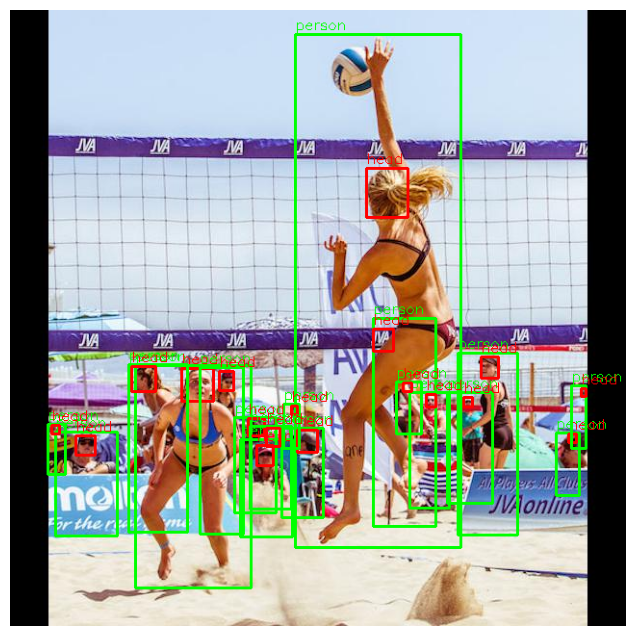

In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt


def visualize_yolo_labels(
    image_path,
    label_path,
    class_names=None,
    save_path=None,
    colors=None,
    thickness=2
):

    img = cv2.imread(image_path)

    if img is None:
        raise ValueError(f"Cannot read image: {image_path}")

    h, w = img.shape[:2]

    # Correct colors for your dataset
    if colors is None:
        colors = {
            0: (0, 0, 255),   # head -> red
            1: (0, 255, 0),   # person -> green
        }

    if not os.path.exists(label_path):
        print(f"Label file not found: {label_path}")
        return img

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:

        parts = line.strip().split()

        if len(parts) != 5:
            continue

        cls_id, xc, yc, bw, bh = map(float, parts)

        cls_id = int(cls_id)

        # YOLO -> pixel coords
        xc *= w
        yc *= h
        bw *= w
        bh *= h

        x1 = int(xc - bw / 2)
        y1 = int(yc - bh / 2)
        x2 = int(xc + bw / 2)
        y2 = int(yc + bh / 2)

        color = colors.get(cls_id, (255, 255, 0))

        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)

        if class_names is not None and cls_id < len(class_names):
            label = class_names[cls_id]
        else:
            label = str(cls_id)

        cv2.putText(
            img,
            label,
            (x1, max(0, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            1
        )

    if save_path is not None:
        cv2.imwrite(save_path, img)

    return img


# CORRECT ORDER
CLASS_NAMES = ["head", "person"]

img = visualize_yolo_labels(
    image_path=r"C:\Users\ROG\ComputerVision\train\images\273271-1039400091556057_jpg.rf.07f90b172cdbc9aff7bcf28ba7682f23.jpg",
    label_path=r"C:\Users\ROG\ComputerVision\train\labels\273271-1039400091556057_jpg.rf.07f90b172cdbc9aff7bcf28ba7682f23.txt",
    class_names=CLASS_NAMES,
    save_path="visualized.jpg"
)

# OpenCV uses BGR, matplotlib uses RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [ ]:
def load_gt_yolo_txt(image_dir, label_dir, label_map={0: 0, 1: 1}):
    """
    image_dir: folder with test images
    label_dir: folder with matching .txt annotation files
    """
    all_gt = []
    image_paths = sorted([
        os.path.join(image_dir, f)
        for f in os.listdir(image_dir)
        if f.endswith((".jpg", ".png"))
    ])

    for img_path in image_paths:
        img = cv2.imread(img_path)
        H, W = img.shape[:2]

        txt_path = os.path.join(
            label_dir,
            os.path.splitext(os.path.basename(img_path))[0] + ".txt"
        )

        boxes, labels = [], []
        if os.path.exists(txt_path):
            with open(txt_path) as f:
                for line in f:
                    cls, cx, cy, w, h = map(float, line.strip().split())
                    x1 = (cx - w/2) * W
                    y1 = (cy - h/2) * H
                    x2 = (cx + w/2) * W
                    y2 = (cy + h/2) * H
                    boxes.append([x1, y1, x2, y2])
                    labels.append(int(cls))

        all_gt.append({"boxes": boxes, "labels": labels})

    return all_gt, image_paths     

In [37]:
from ultralytics import YOLO
from tqdm import tqdm

def get_yolo_predictions(
    model_path,
    image_paths,
    conf_thresh=0.25,
    label_map={0: 0, 1: 1}
):
    """
    model_path:  path to YOLO .pt weights
    image_paths: ordered list of image paths
    label_map:   maps YOLO class index -> internal class id
    """

    model = YOLO(model_path)
    all_pred_yolo = []

    for img_path in tqdm(image_paths, desc="YOLO Inference"):

        results = model(
            img_path,
            conf=conf_thresh,
            verbose=False
        )[0]

        boxes, scores, labels = [], [], []

        for box in results.boxes:

            cls = int(box.cls.item())

            if cls not in label_map:
                continue

            x1, y1, x2, y2 = box.xyxy[0].tolist()

            boxes.append([x1, y1, x2, y2])
            scores.append(float(box.conf.item()))
            labels.append(label_map[cls])

        all_pred_yolo.append({
            "boxes": boxes,
            "scores": scores,
            "labels": labels
        })

    return all_pred_yolo

In [ ]:
import joblib
from tqdm import tqdm
from tqdm_joblib import tqdm_joblib
import numpy as np
from skimage.feature import hog
from joblib import Parallel, delayed

def compute_iou(boxA, boxB):
    xA, yA = max(boxA[0],boxB[0]), max(boxA[1],boxB[1])
    xB, yB = min(boxA[2],boxB[2]), min(boxA[3],boxB[3])
    inter  = max(0,xB-xA)*max(0,yB-yA)
    aA = max(0,(boxA[2]-boxA[0])*(boxA[3]-boxA[1]))
    aB = max(0,(boxB[2]-boxB[0])*(boxB[3]-boxB[1]))
    u  = aA+aB-inter
    return inter/u if u > 0 else 0.0

def nms(boxes, scores, iou_thresh=0.4):
    if len(boxes) == 0:
        return [], []
    boxes  = np.array(boxes,  dtype=np.float32)
    scores = np.array(scores, dtype=np.float32)
    order  = scores.argsort()[::-1]
    keep = []
    while len(order):
        i = order[0]
        keep.append(i)
        ious = np.array([compute_iou(boxes[i], boxes[j]) for j in order[1:]])
        order = order[1:][ious < iou_thresh]
    return boxes[keep].tolist(), scores[keep].tolist()


def sliding_window_predict_fast(svm, image_path, label_int,
                                win_size=(64, 128),
                                step=None,
                                scales=None,
                                conf_thresh=0.0):
    if scales is None:
        scales = DETECT_SCALES
    if step is None:
        step = DETECT_STEP

    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        return [], [], []
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    W_win, H_win = win_size
    raw_boxes, raw_scores = [], []

    for scale in scales:
        new_w = int(img.shape[1] * scale)
        new_h = int(img.shape[0] * scale)

        if new_h < H_win or new_w < W_win:
            continue

        scaled = cv2.resize(img, (new_w, new_h))

        patches, coords = [], []
        for y in range(0, new_h - H_win + 1, step):
            for x in range(0, new_w - W_win + 1, step):
                patches.append(scaled[y:y+H_win, x:x+W_win])
                coords.append((x, y))

        if not patches:
            continue

        feats = np.array([
            hog(p,
                orientations=HOG_ORIENTATIONS,
                pixels_per_cell=HOG_PIXELS_PER_CELL,
                cells_per_block=HOG_CELLS_PER_BLOCK,
                block_norm="L2-Hys",
                transform_sqrt=True)
            for p in patches
        ], dtype=np.float32)

        scores = svm.decision_function(feats)

        mask = scores >= conf_thresh
        for (x, y), score in zip(np.array(coords)[mask], scores[mask]):
            raw_boxes.append([x/scale, y/scale,
                              (x+W_win)/scale, (y+H_win)/scale])
            raw_scores.append(float(score))

    boxes, scores = nms(raw_boxes, raw_scores, iou_thresh=0.4)
    return boxes, scores, [label_int] * len(boxes)


def _process_one_image(img_path, svm_person, svm_head):
    bp, sp, lp = sliding_window_predict_fast(
        svm_person, img_path, label_int=PERSON_CLASS_ID, win_size=PERSON_WINDOW)
    bh, sh, lh = sliding_window_predict_fast(
        svm_head,   img_path, label_int=HEAD_CLASS_ID,   win_size=HEAD_WINDOW)
    return {"boxes": bp+bh, "scores": sp+sh, "labels": lp+lh}


def get_svm_predictions(svm_person, svm_head, image_paths, n_jobs=4):
    print(f"SVM inference on {len(image_paths)} images | {n_jobs} cores | "
          f"{len(DETECT_SCALES)} scales | step={DETECT_STEP}")

    jobs = (
        delayed(_process_one_image)(p, svm_person, svm_head)
        for p in image_paths
    )

    results = list(tqdm(
        Parallel(n_jobs=n_jobs, backend="loky", batch_size=8,
                 return_as="generator")(jobs),
        total=len(image_paths),
        desc="SVM Inference",
        unit="img",
        dynamic_ncols=True,   
    ))

    return results

In [ ]:
from collections import defaultdict

def evaluate_detections(all_pred, all_gt, iou_thresh=0.5):
    """
    all_pred: list of dicts per image
              [{"boxes": [[x1,y1,x2,y2],...], "scores": [...], "labels": [...]}, ...]
    all_gt:   list of dicts per image
              [{"boxes": [[x1,y1,x2,y2],...], "labels": [...]}, ...]
    Returns AP per class and mAP.
    """
    class_preds = defaultdict(list)   # cls -> [(score, tp, fp), ...]
    class_n_gt  = defaultdict(int)

    for preds, gts in zip(all_pred, all_gt):
        # FIX: use explicit shape so empty list gives (0,4) not (0,) — avoids zip crash
        gt_boxes  = np.array(gts["boxes"],  dtype=np.float32).reshape(-1, 4)
        gt_labels = np.array(gts["labels"], dtype=np.int32)
        gt_matched = np.zeros(len(gt_boxes), dtype=bool)

        # Count ground truths per class
        for lbl in gt_labels:
            class_n_gt[int(lbl)] += 1

        # Skip images with no predictions
        if len(preds["scores"]) == 0:
            continue

        order = np.argsort(preds["scores"])[::-1]

        for i in order:
            box   = preds["boxes"][i]
            score = preds["scores"][i]
            lbl   = int(preds["labels"][i])  

            # Find best matching unmatched GT of same class
            best_iou, best_j = 0, -1
            for j in range(len(gt_boxes)):
                if int(gt_labels[j]) != lbl or gt_matched[j]:
                    continue
                iou = compute_iou(box, gt_boxes[j].tolist())
                if iou > best_iou:
                    best_iou, best_j = iou, j

            if best_iou >= iou_thresh:
                gt_matched[best_j] = True
                class_preds[lbl].append((score, 1, 0))  # TP
            else:
                class_preds[lbl].append((score, 0, 1))  # FP

    # Compute AP per class
    aps = {}
    for cls, entries in class_preds.items():
        entries.sort(key=lambda x: -x[0])
        tp_cum = np.cumsum([e[1] for e in entries])
        fp_cum = np.cumsum([e[2] for e in entries])
        n_gt   = class_n_gt[cls]

        recall    = tp_cum / (n_gt + 1e-6)
        precision = tp_cum / (tp_cum + fp_cum + 1e-6)

        # Append sentinel values
        recall    = np.concatenate([[0], recall,    [1]])
        precision = np.concatenate([[1], precision, [0]])

        # Monotonically decreasing envelope
        for k in range(len(precision) - 2, -1, -1):
            precision[k] = max(precision[k], precision[k+1])

        aps[cls] = float(np.trapezoid(precision, recall))

    mAP = float(np.mean(list(aps.values()))) if aps else 0.0
    return aps, mAP


In [40]:
import time

# 1. Load ground truth + get ordered image paths
all_gt, image_paths = load_gt_yolo_txt(VAL_IMAGE_DIR, VAL_LABEL_DIR)
print(f"Loaded {len(image_paths)} validation images")

Loaded 4810 validation images


In [9]:


# 2. YOLO predictions
print("\nRunning YOLO inference...")
t0 = time.time()
all_pred_yolo = get_yolo_predictions("best.pt", image_paths)
print(f"YOLO done in {(time.time()-t0)/60:.1f} min")


Running YOLO inference...


YOLO Inference: 100%|██████████| 4810/4810 [03:29<00:00, 22.96it/s]

YOLO done in 3.5 min


In [ ]:
DETECT_SCALES = [1.0, 0.75, 0.5, 0.35] 
DETECT_STEP   = 16                          


print("\nRunning SVM inference...")
t0 = time.time()
svm_person = joblib.load(os.path.join(SAVE_DIR, "svm_person_final.pkl"))
svm_head   = joblib.load(os.path.join(SAVE_DIR, "svm_head_final.pkl"))
all_pred_svm = get_svm_predictions(svm_person, svm_head, image_paths, n_jobs=6)
print(f"SVM done in {(time.time()-t0)/60:.1f} min")



Running SVM inference...
SVM inference on 4810 images | 6 cores | 4 scales | step=16


SVM Inference: 100%|██████████| 4810/4810 [1:59:47<00:00,  1.49s/img]  


SVM done in 119.8 min


In [ ]:
import pickle

with open("all_pred_svm.pkl", "wb") as f:
    pickle.dump(all_pred_svm, f)

In [ ]:
with open("all_pred_svm.pkl", "rb") as f:
    all_pred_svm = pickle.load(f)

In [ ]:
# 4. Evaluate both
aps_svm,  mAP_svm  = evaluate_detections(all_pred_svm,  all_gt, iou_thresh=0.5)
aps_yolo, mAP_yolo = evaluate_detections(all_pred_yolo, all_gt, iou_thresh=0.5)

CLASS_NAMES = {HEAD_CLASS_ID: "head", PERSON_CLASS_ID: "person"}
print(f"{'Metric':<25} {'SVM':>10} {'YOLO':>10}")
print("-" * 45)
for cls in sorted(aps_svm):
    name = CLASS_NAMES.get(cls, cls)
    print(f"  AP@50 {name:<17} {aps_svm[cls]:>10.3f} {aps_yolo[cls]:>10.3f}")
print(f"  {'mAP@50':<22} {mAP_svm:>10.3f} {mAP_yolo:>10.3f}")

Metric                           SVM       YOLO
---------------------------------------------
  AP@50 head                   0.029      0.742
  AP@50 person                 0.200      0.815
  mAP@50                      0.114      0.778
